In [1]:
"""
ANE(人工噪声增强)+ 加权最小二乘(WLS)MAP 估计器 —— PyTorch 实现
==================================================================
信号模型(Uhlich, IEEE TSP 2015, 式(34)):

    x(n) = cos(theta * n) + v(n),  n = 1..N,
    v(n) ~ N(0, sigma_v^2) i.i.d.,  theta ~ U(0, pi)

本文件包含:

  1) WMAP —— 可微的“加权 MAP”估计器
         theta_hat(x; w) = argmin_theta  sum_n w_n (x(n) - cos(n*theta))^2
     w = 1 时退化为论文中的 MAP(式(35))。
     前向:网格搜索(matmul 展开,不生成 (B,G,N) 大张量)+ 牛顿精化(2~3 步,
           保证 theta_hat 是驻点,这是隐函数定理成立的前提)。
     反向:隐函数定理,式(36)的加权推广:
           D            = sum_n w_n n^2 (1 + cos(n*th) (x_n - 2 cos(n*th)))   ( = f''/2 )
           d th / d x_n = - w_n * n * sin(n*th) / D
           d th / d w_n = - n * sin(n*th) * (x_n - cos(n*th)) / D
     边界 th ∈ {0, pi} 或 D≈0 时梯度置 0(式(36) 只在内点、非退化极小处成立)。
     自检性质:sum_n w_n * dth/dw_n = -f'(th)/(2D) = 0,
     对应 argmin 对 w 整体缩放不变(w 只有 N-1 个有效自由度)。

  2) ANEWLS —— theta_ANE(x) = sum_m p_m * WMAP(x + z_m; w)
     可选学习 {p_m, z_m}(即论文的 ANE,式(29))、学习 w(WLS 权重),
     或两者联合。全部用 Adam + 上述解析梯度端到端训练(最小化贝叶斯 MSE)。

  3) MMSE 基线(网格 + 梯形积分,对应 map_mmse.m)。MMSE 是 SQ 损失下的
     贝叶斯最优估计器,给出可达 MSE 的下界;任何 ANE/WLS 只能缩小
     MAP -> MMSE 之间的差距。

  4) 解析梯度 vs 中心差分的数值校验。

用法:
    python ane_wls_map.py --snr 0 --steps 300 --batch 1024
    python ane_wls_map.py --skip-gradcheck --steps 0        # 只跑基线
备注:噪声方差约定与作者 MATLAB 代码一致:sigma_v^2 = 2 * 10^(-SNR/10)。
"""

import argparse
import math

import torch
import torch.nn as nn
import torch.nn.functional as F


# ---------------------------------------------------------------------------
# 网格与公共计算(对应 map.m 中的 persistent 变量)
# ---------------------------------------------------------------------------
class Grid:
    def __init__(self, N, G, device="cpu", dtype=torch.float32):
        self.N, self.G = N, G
        self.n = torch.arange(1, N + 1, device=device, dtype=dtype)                # (N,)
        self.theta = torch.linspace(0.0, math.pi, G, device=device, dtype=dtype)   # (G,)
        self.C = torch.cos(self.theta[:, None] * self.n[None, :])                  # (G,N)
        self.Csq = self.C * self.C                                                 # (G,N)


def weighted_residuals(x, w, grid):
    """R[b,g] = sum_n w_n (x[b,n] - C[g,n])^2,用展开式
       sum w x^2 - 2 (w*x) C^T + sum w C^2  避免 (B,G,N) 中间张量。"""
    xw = x * w                                   # (B,N)
    t1 = (xw * x).sum(dim=1, keepdim=True)       # (B,1)
    t2 = xw @ grid.C.T                           # (B,G)
    t3 = grid.Csq @ w                            # (G,)
    return t1 - 2.0 * t2 + t3[None, :]


def f_derivs(x, w, th, n):
    """f(th) = sum_n w_n (x_n - cos(n th))^2 的一、二阶导(逐样本)。"""
    thc = th[:, None]
    c = torch.cos(thc * n)
    s = torch.sin(thc * n)
    fp = 2.0 * (w * n * s * (x - c)).sum(dim=1)
    fpp = 2.0 * (w * (n ** 2) * (1.0 + c * (x - 2.0 * c))).sum(dim=1)
    return fp, fpp


# ---------------------------------------------------------------------------
# 可微加权 MAP(w=1 时即论文的 MAP + 式(36))
# ---------------------------------------------------------------------------
class WMAP(torch.autograd.Function):
    NEWTON_STEPS = 3
    BOUNDARY_EPS = 1e-6

    @staticmethod
    def forward(ctx, x, w, grid):
        R = weighted_residuals(x, w, grid)               # (B,G)
        th = grid.theta[R.argmin(dim=1)]                 # (B,)
        # 牛顿精化:把网格解推到真正的驻点(相当于 map.m 的抛物线插值,但更精确)
        for _ in range(WMAP.NEWTON_STEPS):
            fp, fpp = f_derivs(x, w, th, grid.n)
            th = (th - fp / fpp.clamp_min(1e-12)).clamp_(0.0, math.pi)
        ctx.save_for_backward(x, w, th, grid.n)
        return th

    @staticmethod
    def backward(ctx, gout):
        x, w, th, n = ctx.saved_tensors
        thc = th[:, None]
        c = torch.cos(thc * n)
        s = torch.sin(thc * n)
        D = (w * (n ** 2) * (1.0 + c * (x - 2.0 * c))).sum(dim=1, keepdim=True)  # = f''/2
        # 式(36) 只对内点 (0,pi) 且非退化极小 (D>0) 成立;否则估计器局部常数 -> 梯度 0
        interior = ((th > WMAP.BOUNDARY_EPS)
                    & (th < math.pi - WMAP.BOUNDARY_EPS)
                    & (D.squeeze(1) > 1e-9))[:, None]
        Dsafe = D.clamp_min(1e-9)
        gx_rows = torch.where(interior, -(w * n * s) / Dsafe, torch.zeros_like(x))
        gw_rows = torch.where(interior, -(n * s * (x - c)) / Dsafe, torch.zeros_like(x))
        gx = gout[:, None] * gx_rows
        gw = (gout[:, None] * gw_rows).sum(dim=0)        # 对 batch 累加 -> 形状同 w
        return gx, gw, None


def map_estimate(x, grid):
    """论文式(35)的普通 MAP(= w 全 1 的 WMAP)。"""
    w1 = torch.ones(grid.N, device=x.device, dtype=x.dtype)
    return WMAP.apply(x, w1, grid)


@torch.no_grad()
def mmse_estimate(x, sigma2, grid):
    """MMSE = 后验均值(均匀先验),网格 + 梯形积分;对应 map_mmse.m。"""
    w1 = torch.ones(grid.N, device=x.device, dtype=x.dtype)
    R = weighted_residuals(x, w1, grid)
    lp = -R / (2.0 * sigma2)
    lp -= lp.max(dim=1, keepdim=True).values             # 数值稳定
    post = torch.exp(lp)
    trap = getattr(torch, "trapezoid", torch.trapz)
    num = trap(grid.theta[None, :] * post, grid.theta, dim=1)
    den = trap(post, grid.theta, dim=1)
    return num / den


# ---------------------------------------------------------------------------
# ANE + WLS 模块
# ---------------------------------------------------------------------------
class ANEWLS(nn.Module):
    """theta_hat(x) = sum_m p_m * WMAP(x + z_m; w)
       learn_noise=True  -> 学 {p_m, z_m}(论文的 ANE)
       learn_weights=True -> 学 w(加权最小二乘)"""

    def __init__(self, grid, M=5, learn_noise=True, learn_weights=True, z_init=0.1):
        super().__init__()
        self.grid = grid
        self.N = grid.N
        dt, dev = grid.theta.dtype, grid.theta.device
        if learn_noise:
            self.M = M
            self.z = nn.Parameter(z_init * torch.randn(M, self.N, dtype=dt, device=dev))
            self.p_logits = nn.Parameter(torch.zeros(M, dtype=dt, device=dev))
        else:
            self.M = 1
            self.register_buffer("z", torch.zeros(1, self.N, dtype=dt, device=dev))
            self.register_buffer("p_logits", torch.zeros(1, dtype=dt, device=dev))
        if learn_weights:
            self.w_logits = nn.Parameter(torch.zeros(self.N, dtype=dt, device=dev))
        else:
            self.w_logits = None

    def weights(self):
        if self.w_logits is None:
            return torch.ones(self.N, dtype=self.grid.theta.dtype,
                              device=self.grid.theta.device)
        w = F.softplus(self.w_logits) + 1e-8
        return w * (self.N / w.sum())      # 归一化 sum(w)=N;argmin 对整体缩放不变

    def forward(self, x):
        B = x.shape[0]
        p = torch.softmax(self.p_logits, dim=0)
        w = self.weights()
        # 把 M 个分量堆成一批,只做一次网格搜索
        xz = (x.unsqueeze(0) + self.z.unsqueeze(1)).reshape(self.M * B, self.N)
        th = WMAP.apply(xz, w, self.grid).view(self.M, B)
        return (p[:, None] * th).sum(dim=0)


# ---------------------------------------------------------------------------
# 训练 / 评估
# ---------------------------------------------------------------------------
def sample_data(B, sigma, grid, generator=None):
    dev, dt = grid.theta.device, grid.theta.dtype
    theta = torch.rand(B, device=dev, dtype=dt, generator=generator) * math.pi
    x = torch.cos(theta[:, None] * grid.n[None, :]) \
        + sigma * torch.randn(B, grid.N, device=dev, dtype=dt, generator=generator)
    return theta, x


def train_model(model, sigma, steps, batch, lr, tag, log_every=50):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for t in range(1, steps + 1):
        theta, x = sample_data(batch, sigma, model.grid)   # 每步新采样 = 随机逼近贝叶斯风险
        loss = ((model(x) - theta) ** 2).mean()
        opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)  # 防止 D 很小时梯度尖峰
        opt.step()
        if t == 1 or t % log_every == 0:
            print(f"  [{tag}] step {t:4d}   batch-MSE = {loss.item():.5f}")
    return model


@torch.no_grad()
def eval_mse(fn, theta, x, chunk=2000):
    se = []
    for i in range(0, x.shape[0], chunk):
        se.append((fn(x[i:i + chunk]) - theta[i:i + chunk]) ** 2)
    return torch.cat(se).mean().item()


# ---------------------------------------------------------------------------
# 梯度校验:解析(IFT) vs 中心差分
# ---------------------------------------------------------------------------
def gradient_check(num_trials=20, seed=123):
    print("== 梯度校验: 隐函数定理(解析) vs 中心差分(float64, G=20000) ==")
    torch.manual_seed(seed)
    dt = torch.float64
    g = Grid(5, 20000, "cpu", dt)
    h = 1e-6
    max_ex = max_ew = 0.0
    scale_inv = 0.0
    used = 0
    for _ in range(num_trials):
        th0 = torch.rand(1, dtype=dt) * math.pi
        x = (torch.cos(th0 * g.n)[None, :] + 0.6 * torch.randn(1, 5, dtype=dt))
        w = 0.5 + torch.rand(5, dtype=dt)
        x.requires_grad_(True)
        w.requires_grad_(True)
        th = WMAP.apply(x, w, g)
        if th.item() < 1e-3 or th.item() > math.pi - 1e-3:
            continue                                   # 只校验内点(边界处梯度定义为 0)
        gx, gw = torch.autograd.grad(th.sum(), [x, w])
        with torch.no_grad():
            gx_fd = torch.zeros_like(x)
            gw_fd = torch.zeros_like(w)
            for i in range(5):
                e = torch.zeros_like(x); e[0, i] = h
                gx_fd[0, i] = (WMAP.apply(x + e, w, g) - WMAP.apply(x - e, w, g)).item() / (2 * h)
                ew = torch.zeros_like(w); ew[i] = h
                gw_fd[i] = (WMAP.apply(x, w + ew, g) - WMAP.apply(x, w - ew, g)).item() / (2 * h)
        ex = ((gx - gx_fd).abs().max() / gx_fd.abs().max().clamp_min(1e-12)).item()
        ew_ = ((gw - gw_fd).abs().max() / gw_fd.abs().max().clamp_min(1e-12)).item()
        max_ex, max_ew = max(max_ex, ex), max(max_ew, ew_)
        scale_inv = max(scale_inv, abs((w.detach() * gw).sum().item()))
        used += 1
    print(f"  内点样本 {used}/{num_trials}   max rel.err  dθ/dx: {max_ex:.2e}   dθ/dw: {max_ew:.2e}")
    print(f"  尺度不变性 |sum_n w_n dθ/dw_n| 最大值: {scale_inv:.2e}  (理论值 0)\n")


# ---------------------------------------------------------------------------
def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--snr", type=float, default=0.0)
    ap.add_argument("--N", type=int, default=5)
    ap.add_argument("--M", type=int, default=5)
    ap.add_argument("--grid", type=int, default=4000)
    ap.add_argument("--steps", type=int, default=300)
    ap.add_argument("--batch", type=int, default=1024)
    ap.add_argument("--lr", type=float, default=2e-2)
    ap.add_argument("--test-size", type=int, default=20000)
    ap.add_argument("--seed", type=int, default=0)
    ap.add_argument("--skip-gradcheck", action="store_true")
    args, unknown = ap.parse_known_args()

    dev = "cuda" if torch.cuda.is_available() else "cpu"
    dt = torch.float32
    sigma2 = 2.0 * 10 ** (-args.snr / 10.0)     # 与 MATLAB 代码同一约定
    sigma = math.sqrt(sigma2)
    grid = Grid(args.N, args.grid, dev, dt)
    print(f"device={dev}, N={args.N}, G={args.grid}, SNR={args.snr} dB, sigma^2={sigma2:.4f}\n")

    if not args.skip_gradcheck:
        gradient_check()

    # 固定测试集(与训练数据独立)
    gen = torch.Generator(device=dev); gen.manual_seed(args.seed + 999)
    th_te, x_te = sample_data(args.test_size, sigma, grid, generator=gen)

    results = {}
    results["MAP  (基线, 式35)"] = eval_mse(lambda x: map_estimate(x, grid), th_te, x_te)
    results["MMSE (贝叶斯下界)"] = eval_mse(lambda x: mmse_estimate(x, sigma2, grid), th_te, x_te)

    if args.steps > 0:
        variants = {
            "ANE      (学 p,z)": dict(learn_noise=True, learn_weights=False),
            "WLS      (学 w)  ": dict(learn_noise=False, learn_weights=True),
            "ANE+WLS  (联合)  ": dict(learn_noise=True, learn_weights=True),
        }
        for name, cfg in variants.items():
            print(f"-- 训练 {name.strip()} --")
            torch.manual_seed(args.seed)                 # 相同初始化,便于对比
            model = ANEWLS(grid, M=args.M, **cfg)
            train_model(model, sigma, args.steps, args.batch, args.lr, tag=name.strip())
            results[name] = eval_mse(model, th_te, x_te)
            with torch.no_grad():
                if model.w_logits is not None:
                    print("   学到的权重 w =", model.weights().cpu().numpy().round(3))
                if isinstance(model.z, nn.Parameter):
                    print("   学到的 p =", torch.softmax(model.p_logits, 0).cpu().numpy().round(3))
                    print("   学到的 z =\n", model.z.detach().cpu().numpy().round(3))
            print()

    print("=" * 72)
    print(f"结果汇总  (SNR = {args.snr:g} dB,  测试样本 {args.test_size})")
    mse_map, mse_mmse = results["MAP  (基线, 式35)"], results["MMSE (贝叶斯下界)"]
    gap = mse_map - mse_mmse
    for k, v in results.items():
        imp = (mse_map - v) / mse_map * 100.0
        closed = (mse_map - v) / gap * 100.0 if gap > 0 else float("nan")
        print(f"  {k}:  MSE = {v:.5f}   vs MAP: {imp:+6.2f}%   MAP→MMSE 差距弥合: {closed:6.1f}%")


if __name__ == "__main__":
    main()

device=cuda, N=5, G=4000, SNR=0.0 dB, sigma^2=2.0000

== 梯度校验: 隐函数定理(解析) vs 中心差分(float64, G=20000) ==
  内点样本 18/20   max rel.err  dθ/dx: 1.94e-09   dθ/dw: 2.73e-09
  尺度不变性 |sum_n w_n dθ/dw_n| 最大值: 1.73e-16  (理论值 0)

-- 训练 ANE      (学 p,z) --
  [ANE      (学 p,z)] step    1   batch-MSE = 0.96818
  [ANE      (学 p,z)] step   50   batch-MSE = 0.74931
  [ANE      (学 p,z)] step  100   batch-MSE = 0.74347
  [ANE      (学 p,z)] step  150   batch-MSE = 0.71013
  [ANE      (学 p,z)] step  200   batch-MSE = 0.76017
  [ANE      (学 p,z)] step  250   batch-MSE = 0.63060
  [ANE      (学 p,z)] step  300   batch-MSE = 0.66276
   学到的 p = [0.181 0.149 0.17  0.344 0.156]
   学到的 z =
 [[-0.047 -1.924 -0.435  0.539  0.911]
 [-2.009 -2.15  -0.269  1.001 -0.455]
 [-2.281 -2.178 -0.858  1.72  -1.405]
 [ 2.632 -2.471 -0.874  0.459  1.268]
 [-0.519 -2.097  0.814  1.237  0.255]]

-- 训练 WLS      (学 w) --
  [WLS      (学 w)] step    1   batch-MSE = 0.95889
  [WLS      (学 w)] step   50   batch-MSE = 0.99077
  [WLS      (学

In [4]:
"""
verify_numpy.py —— ane_wls_map.py(PyTorch 版)的 NumPy 数值验证双胞胎
====================================================================
与 PyTorch 版逐式对应:同一前向(网格搜索 + 牛顿精化)、同一隐函数定理梯度
(式(36)及其加权推广)、手写 Adam。用途:
  (1) 中心差分校验解析梯度 dθ/dx、dθ/dw;
  (2) 在给定 SNR 下完整训练 ANE / WLS / ANE+WLS 并与 MAP、MMSE 对比。
"""
import math
import numpy as np

rng = np.random.default_rng(0)


# ----------------------------- 公共部分 -----------------------------
class Grid:
    def __init__(self, N, G):
        self.N, self.G = N, G
        self.n = np.arange(1, N + 1, dtype=np.float64)
        self.theta = np.linspace(0.0, math.pi, G)
        self.C = np.cos(self.theta[:, None] * self.n[None, :])   # (G,N)
        self.Csq = self.C ** 2


def wres(x, w, grid):
    xw = x * w
    return (xw * x).sum(1, keepdims=True) - 2.0 * xw @ grid.C.T + (grid.Csq @ w)[None, :]


def f_derivs(x, w, th, n):
    c = np.cos(th[:, None] * n)
    s = np.sin(th[:, None] * n)
    fp = 2.0 * (w * n * s * (x - c)).sum(1)
    fpp = 2.0 * (w * n ** 2 * (1.0 + c * (x - 2.0 * c))).sum(1)
    return fp, fpp


def wmap(x, w, grid, newton=3):
    """theta_hat = argmin_th sum_n w_n (x_n - cos(n th))^2 ,  th in [0,pi]"""
    R = wres(x, w, grid)
    th = grid.theta[R.argmin(1)]
    for _ in range(newton):
        fp, fpp = f_derivs(x, w, th, grid.n)
        th = np.clip(th - fp / np.maximum(fpp, 1e-12), 0.0, math.pi)
    return th


def wmap_grads(x, w, th, n):
    """隐函数定理:
       dθ/dx_n = -w_n n sin(nθ)/D ,  dθ/dw_n = -n sin(nθ)(x_n-cos(nθ))/D
       D = sum_n w_n n^2 (1+cos(nθ)(x_n-2cos(nθ)));  边界/退化处梯度=0"""
    c = np.cos(th[:, None] * n)
    s = np.sin(th[:, None] * n)
    D = (w * n ** 2 * (1.0 + c * (x - 2.0 * c))).sum(1, keepdims=True)
    interior = ((th > 1e-6) & (th < math.pi - 1e-6) & (D[:, 0] > 1e-9))[:, None]
    Ds = np.maximum(D, 1e-9)
    gx = np.where(interior, -(w * n * s) / Ds, 0.0)
    gw = np.where(interior, -(n * s * (x - c)) / Ds, 0.0)
    return gx, gw


def mmse(x, sigma2, grid):
    lp = -wres(x, np.ones(grid.N), grid) / (2.0 * sigma2)
    lp -= lp.max(1, keepdims=True)
    post = np.exp(lp)
    num = np.trapz(grid.theta[None, :] * post, grid.theta, axis=1)
    den = np.trapz(post, grid.theta, axis=1)
    return num / den


# ----------------------------- 梯度校验 -----------------------------
def gradient_check(trials=25):
    print("== 梯度校验:解析(IFT) vs 中心差分 (float64, G=20000) ==")
    g = Grid(5, 20000)
    h = 1e-6
    mex = mew = sinv = 0.0
    used = 0
    for _ in range(trials):
        th0 = rng.uniform(0, math.pi)
        x = np.cos(th0 * g.n)[None, :] + 0.6 * rng.standard_normal((1, 5))
        w = 0.5 + rng.uniform(size=5)
        th = wmap(x, w, g)
        if th[0] < 1e-3 or th[0] > math.pi - 1e-3:
            continue
        gx, gw = wmap_grads(x, w, th, g.n)
        gx_fd = np.zeros(5)
        gw_fd = np.zeros(5)
        for i in range(5):
            e = np.zeros((1, 5)); e[0, i] = h
            gx_fd[i] = (wmap(x + e, w, g)[0] - wmap(x - e, w, g)[0]) / (2 * h)
            ew = np.zeros(5); ew[i] = h
            gw_fd[i] = (wmap(x, w + ew, g)[0] - wmap(x, w - ew, g)[0]) / (2 * h)
        mex = max(mex, np.abs(gx[0] - gx_fd).max() / max(np.abs(gx_fd).max(), 1e-12))
        mew = max(mew, np.abs(gw[0] - gw_fd).max() / max(np.abs(gw_fd).max(), 1e-12))
        sinv = max(sinv, abs((w * gw[0]).sum()))
        used += 1
    print(f"  内点样本 {used}/{trials}   max rel.err  dθ/dx: {mex:.2e}   dθ/dw: {mew:.2e}")
    print(f"  尺度不变性 |Σ_n w_n ∂θ/∂w_n| 最大值: {sinv:.2e}  (理论 0)\n")


# ----------------------------- 手写 Adam -----------------------------
class Adam:
    def __init__(self, shapes, lr=2e-2, b1=0.9, b2=0.999, eps=1e-8):
        self.lr, self.b1, self.b2, self.eps, self.t = lr, b1, b2, eps, 0
        self.m = [np.zeros(s) for s in shapes]
        self.v = [np.zeros(s) for s in shapes]

    def step(self, params, grads, clip=5.0):
        gn = math.sqrt(sum((g ** 2).sum() for g in grads))
        sc = min(1.0, clip / (gn + 1e-12))
        self.t += 1
        for i, (p, g) in enumerate(zip(params, grads)):
            g = g * sc
            self.m[i] = self.b1 * self.m[i] + (1 - self.b1) * g
            self.v[i] = self.b2 * self.v[i] + (1 - self.b2) * g * g
            mh = self.m[i] / (1 - self.b1 ** self.t)
            vh = self.v[i] / (1 - self.b2 ** self.t)
            p -= self.lr * mh / (np.sqrt(vh) + self.eps)


def softplus(x):
    return np.logaddexp(0.0, x)


def softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()


# --------------------------- ANE+WLS 训练 ---------------------------
class Model:
    def __init__(self, grid, M, learn_noise, learn_weights, seed=0):
        r = np.random.default_rng(seed)
        self.grid, self.learn_noise, self.learn_weights = grid, learn_noise, learn_weights
        self.M = M if learn_noise else 1
        self.z = 0.1 * r.standard_normal((self.M, grid.N)) if learn_noise \
            else np.zeros((1, grid.N))
        self.p_logits = np.zeros(self.M)
        self.w_logits = np.zeros(grid.N)

    # ---- 参数 -> 有效量 ----
    def weights(self):
        if not self.learn_weights:
            return np.ones(self.grid.N)
        w = softplus(self.w_logits) + 1e-8
        return w * (self.grid.N / w.sum())

    def forward(self, x):
        w, p = self.weights(), softmax(self.p_logits)
        th = np.stack([wmap(x + self.z[m], w, self.grid) for m in range(self.M)])
        return (p[:, None] * th).sum(0)

    # ---- 前向 + 手写反向(链式法则,梯度全为解析式) ----
    def loss_and_grads(self, x, theta):
        B, N = x.shape
        w, p = self.weights(), softmax(self.p_logits)
        th = np.zeros((self.M, B))
        gx = [None] * self.M
        gw_rows = [None] * self.M
        for m in range(self.M):
            xm = x + self.z[m]
            th[m] = wmap(xm, w, self.grid)
            gx[m], gw_rows[m] = wmap_grads(xm, w, th[m], self.grid.n)
        pred = (p[:, None] * th).sum(0)
        err = pred - theta
        loss = (err ** 2).mean()

        dpred = 2.0 * err / B                       # (B,)
        dth = p[:, None] * dpred[None, :]           # (M,B)
        dz = np.stack([(dth[m][:, None] * gx[m]).sum(0) for m in range(self.M)])
        dw_eff = sum((dth[m][:, None] * gw_rows[m]).sum(0) for m in range(self.M))
        dp = (dpred[None, :] * th).sum(1)
        dpl = p * (dp - (p * dp).sum())              # softmax 反向
        if self.learn_weights:                       # 归一化 + softplus 反向
            wr = softplus(self.w_logits) + 1e-8
            c = self.grid.N / wr.sum()
            dwr = c * (dw_eff - (dw_eff * wr).sum() / wr.sum())
            dwl = dwr / (1.0 + np.exp(-self.w_logits))
        else:
            dwl = np.zeros_like(self.w_logits)
        if not self.learn_noise:
            dz = np.zeros_like(self.z)
            dpl = np.zeros_like(self.p_logits)
        return loss, [dz, dpl, dwl]


def sample(B, sigma, grid, r):
    theta = r.uniform(0, math.pi, B)
    x = np.cos(theta[:, None] * grid.n[None, :]) + sigma * r.standard_normal((B, grid.N))
    return theta, x


def train(model, sigma, steps, batch, lr, tag, seed=0):
    r = np.random.default_rng(seed + 1)
    opt = Adam([model.z.shape, model.p_logits.shape, model.w_logits.shape], lr=lr)
    for t in range(1, steps + 1):
        theta, x = sample(batch, sigma, model.grid, r)
        loss, grads = model.loss_and_grads(x, theta)
        opt.step([model.z, model.p_logits, model.w_logits], grads)
        if t == 1 or t % 50 == 0:
            print(f"  [{tag}] step {t:4d}   batch-MSE = {loss:.5f}")
    return model


def eval_mse(fn, theta, x, chunk=2000):
    se = [ (fn(x[i:i+chunk]) - theta[i:i+chunk])**2 for i in range(0, len(theta), chunk) ]
    return float(np.concatenate(se).mean())


# --------------------------------- main ---------------------------------
if __name__ == "__main__":
    import argparse
    ap = argparse.ArgumentParser()
    ap.add_argument("--snr", type=float, default=0.0)
    ap.add_argument("--N", type=int, default=5)
    ap.add_argument("--M", type=int, default=5)
    ap.add_argument("--grid", type=int, default=4000)
    ap.add_argument("--steps", type=int, default=300)
    ap.add_argument("--batch", type=int, default=1024)
    ap.add_argument("--lr", type=float, default=2e-2)
    ap.add_argument("--test-size", type=int, default=20000)
    args, unknown = ap.parse_known_args()

    sigma2 = 2.0 * 10 ** (-args.snr / 10.0)   # 与 MATLAB 代码同一约定
    sigma = math.sqrt(sigma2)
    grid = Grid(args.N, args.grid)
    print(f"N={args.N}, G={args.grid}, SNR={args.snr} dB, sigma^2={sigma2:.4f}\n")

    gradient_check()

    rt = np.random.default_rng(999)
    th_te, x_te = sample(args.test_size, sigma, grid, rt)

    res = {}
    res["MAP  (基线,式35)"] = eval_mse(lambda x: wmap(x, np.ones(grid.N), grid), th_te, x_te)
    res["MMSE (贝叶斯下界)"] = eval_mse(lambda x: mmse(x, sigma2, grid), th_te, x_te)

    variants = {
        "ANE      (学 p,z)": dict(learn_noise=True,  learn_weights=False),
        "WLS      (学 w)  ": dict(learn_noise=False, learn_weights=True),
        "ANE+WLS  (联合)  ": dict(learn_noise=True,  learn_weights=True),
    }
    for name, cfg in variants.items():
        print(f"-- 训练 {name.strip()} --")
        model = Model(grid, args.M, seed=0, **cfg)
        train(model, sigma, args.steps, args.batch, args.lr, tag=name.strip())
        res[name] = eval_mse(model.forward, th_te, x_te)
        if cfg["learn_weights"]:
            print("   学到的权重 w =", model.weights().round(3))
        if cfg["learn_noise"]:
            print("   学到的 p =", softmax(model.p_logits).round(3))
            print("   学到的 z =\n", model.z.round(3))
        print()

    print("=" * 72)
    print(f"结果汇总  (SNR = {args.snr:g} dB, 测试样本 {args.test_size})")
    m0, mm = res["MAP  (基线,式35)"], res["MMSE (贝叶斯下界)"]
    gap = m0 - mm
    for k, v in res.items():
        print(f"  {k}:  MSE = {v:.5f}   vs MAP: {(m0-v)/m0*100:+6.2f}%"
              f"   MAP→MMSE 差距弥合: {(m0-v)/gap*100:6.1f}%")

N=5, G=4000, SNR=0.0 dB, sigma^2=2.0000

== 梯度校验:解析(IFT) vs 中心差分 (float64, G=20000) ==
  内点样本 22/25   max rel.err  dθ/dx: 1.77e-09   dθ/dw: 1.06e-08
  尺度不变性 |Σ_n w_n ∂θ/∂w_n| 最大值: 9.16e-16  (理论 0)

-- 训练 ANE      (学 p,z) --
  [ANE      (学 p,z)] step    1   batch-MSE = 0.89922
  [ANE      (学 p,z)] step   50   batch-MSE = 0.76455
  [ANE      (学 p,z)] step  100   batch-MSE = 0.71247
  [ANE      (学 p,z)] step  150   batch-MSE = 0.65725
  [ANE      (学 p,z)] step  200   batch-MSE = 0.69997
  [ANE      (学 p,z)] step  250   batch-MSE = 0.68497
  [ANE      (学 p,z)] step  300   batch-MSE = 0.64225
   学到的 p = [0.365 0.114 0.173 0.252 0.096]
   学到的 z =
 [[ 2.659 -2.267 -0.789  0.796  0.34 ]
 [-0.569 -2.071 -0.291  1.205 -1.417]
 [ 0.134 -1.913 -0.008  0.437  0.989]
 [-2.47  -2.033 -0.219  0.849  0.148]
 [-0.506 -2.154  0.262  1.207  1.199]]

-- 训练 WLS      (学 w) --
  [WLS      (学 w)] step    1   batch-MSE = 0.93965
  [WLS      (学 w)] step   50   batch-MSE = 0.91212
  [WLS      (学 w)] step  100   b

开始序贯在线学习...
Step  500 | EKF Instantaneous MSE: 0.7063
Step 1000 | EKF Instantaneous MSE: 0.8100
Step 1500 | EKF Instantaneous MSE: 0.6670
Step 2000 | EKF Instantaneous MSE: 0.7401
Step 2500 | EKF Instantaneous MSE: 0.7496
Step 3000 | EKF Instantaneous MSE: 0.7252


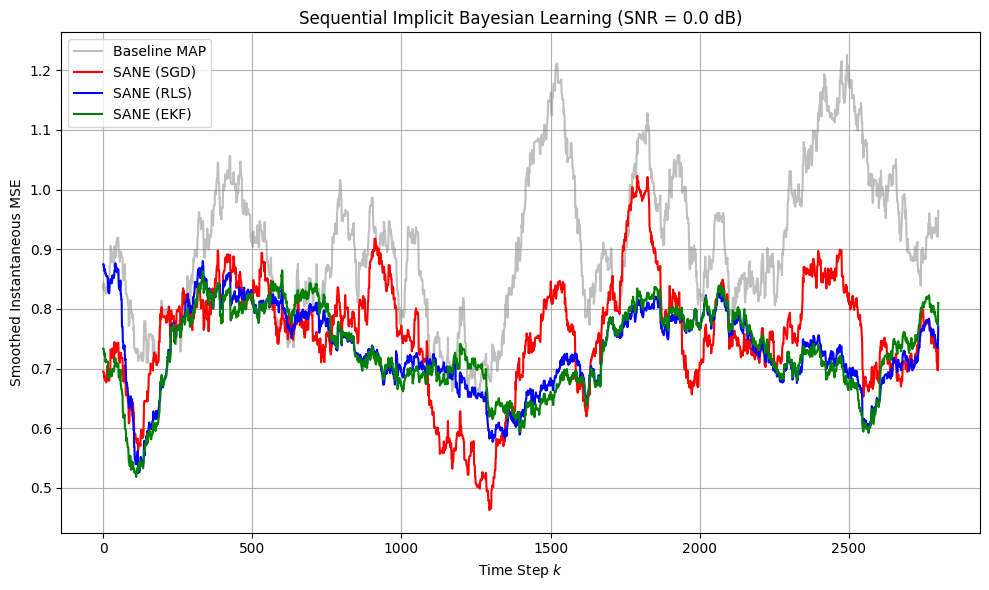

In [5]:
import math
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------- 基础网格与隐函数估计器 -----------------------------
class Grid:
    def __init__(self, N, G=2000):
        self.N = N
        self.G = G
        self.n = np.arange(1, N + 1, dtype=np.float64)
        self.theta = np.linspace(0.0, math.pi, G)
        self.C = np.cos(self.theta[:, None] * self.n[None, :])
        self.Csq = self.C ** 2

def wres_single(x, z, grid):
    # 带有注入噪声 z 的单样本残差计算
    xz = x + z
    return np.sum(xz**2) - 2.0 * (xz @ grid.C.T) + np.sum(grid.Csq, axis=1)

def map_estimate_and_grad(x, z, grid):
    """
    计算前向估计值 theta_hat，以及 IFT 梯度 g = d(theta_hat)/dz
    x, z shape: (N,)
    """
    xz = x + z
    R = wres_single(x, z, grid)
    
    # 前向 MAP 估计 (网格搜索 + 牛顿插值可在此处扩展，此处保持基础搜索以保证速度)
    idx = R.argmin()
    th = grid.theta[idx]
    
    # IFT 隐函数定理计算梯度
    n = grid.n
    c = np.cos(th * n)
    s = np.sin(th * n)
    
    # 极值点二阶导数 (分母)
    fpp = np.sum(n**2 * (1.0 + c * (xz - 2.0 * c)))
    
    # 内部点梯度，如果落在边界则梯度置零
    if 1e-3 < th < math.pi - 1e-3 and fpp > 1e-9:
        gx = -(n * s) / fpp
    else:
        gx = np.zeros_like(xz)
        
    return th, gx

# ----------------------------- 隐式序贯贝叶斯学习器 (SANE Framework) -----------------------------
class ImplicitSequentialLearner:
    def __init__(self, N, method='sgd', alpha=0.05, lam=0.999, R=1.0, Q=1e-5, P0=1.0):
        """
        统一框架: \phi_{k+1} = \phi_k + \Gamma_k e_k g_k
        """
        self.method = method.lower()
        self.phi = np.zeros(N)  # 待优化的参数，此处以人工噪声 z 为例
        self.N = N
        
        # SGD 参数
        self.alpha = alpha
        
        # RLS 参数
        self.lam = lam  # 遗忘因子 (Forgetting factor)
        
        # EKF 参数
        self.R = R      # 观测噪声协方差
        self.Q = Q * np.eye(N)  # 状态过程噪声协方差
        
        # 共享协方差矩阵初始化
        self.P = P0 * np.eye(N)

    def step(self, e_k, g_k):
        """
        根据不同的增益结构更新参数
        e_k: 标量误差 (theta_k - theta_hat_k)
        g_k: 梯度向量 (N,)
        """
        # 防止异常梯度破坏协方差矩阵
        if np.linalg.norm(g_k) == 0:
            return self.phi
            
        g_k = g_k.reshape(-1, 1) # (N, 1)
        
        if self.method == 'sgd':
            # SGD 增益: \Gamma_k = \alpha I
            self.phi = self.phi + self.alpha * e_k * g_k.flatten()
            
        elif self.method == 'rls':
            # RLS 增益: K_k = P_k g_k / (\lambda + g_k^T P_k g_k)
            den = self.lam + (g_k.T @ self.P @ g_k)[0, 0]
            K_k = (self.P @ g_k) / den
            
            self.phi = self.phi + (K_k * e_k).flatten()
            self.P = (1.0 / self.lam) * (self.P - K_k @ g_k.T @ self.P)
            
        elif self.method == 'ekf':
            # EKF 增益: 包含状态演化预测
            P_prior = self.P + self.Q
            den = (g_k.T @ P_prior @ g_k)[0, 0] + self.R
            K_k = (P_prior @ g_k) / den
            
            self.phi = self.phi + (K_k * e_k).flatten()
            self.P = (np.eye(self.N) - K_k @ g_k.T) @ P_prior
            
        return self.phi

# ----------------------------- 序贯在线学习仿真 -----------------------------
def run_sequential_simulation():
    N = 5
    K_steps = 3000
    snr_db = 0.0
    sigma = math.sqrt(2.0 * 10 ** (-snr_db / 10.0))
    grid = Grid(N, G=3000)
    
    rng = np.random.default_rng(42)
    
    # 初始化三种学习器
    learner_sgd = ImplicitSequentialLearner(N, method='sgd', alpha=0.1)
    learner_rls = ImplicitSequentialLearner(N, method='rls', lam=0.999, P0=1.0)
    learner_ekf = ImplicitSequentialLearner(N, method='ekf', R=0.5, Q=1e-5, P0=1.0)
    
    mse_history = {'baseline': [], 'sgd': [], 'rls': [], 'ekf': []}
    
    print("开始序贯在线学习...")
    for k in range(K_steps):
        # 1. 产生时刻 k 的新数据 (允许 theta 随时间缓慢漂移，或保持独立随机分布)
        theta_k = rng.uniform(0.1, math.pi - 0.1)
        v_k = sigma * rng.standard_normal(N)
        x_k = np.cos(theta_k * grid.n) + v_k
        
        # 2. 基线 (无人工噪声)
        th_base, _ = map_estimate_and_grad(x_k, np.zeros(N), grid)
        mse_history['baseline'].append((theta_k - th_base)**2)
        
        # 3. 序贯更新逻辑
        for name, learner in zip(['sgd', 'rls', 'ekf'], [learner_sgd, learner_rls, learner_ekf]):
            # 提取当前参数 (此处为人工噪声 z)
            z_k = learner.phi
            
            # 估计当前频率及隐式梯度
            th_hat_k, g_k = map_estimate_and_grad(x_k, z_k, grid)
            
            # 计算误差
            e_k = theta_k - th_hat_k
            
            # 执行一步状态更新
            learner.step(e_k, g_k)
            
            # 记录瞬时误差
            mse_history[name].append(e_k**2)
            
        if (k + 1) % 500 == 0:
            print(f"Step {k+1:4d} | EKF Instantaneous MSE: {np.mean(mse_history['ekf'][-500:]):.4f}")

    # ----------------------------- 结果平滑与可视化 -----------------------------
    def moving_average(data, window_size=200):
        return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

    plt.figure(figsize=(10, 6))
    plt.plot(moving_average(mse_history['baseline']), label='Baseline MAP', color='gray', alpha=0.5)
    plt.plot(moving_average(mse_history['sgd']), label='SANE (SGD)', color='red')
    plt.plot(moving_average(mse_history['rls']), label='SANE (RLS)', color='blue')
    plt.plot(moving_average(mse_history['ekf']), label='SANE (EKF)', color='green')
    
    plt.xlabel('Time Step $k$')
    plt.ylabel('Smoothed Instantaneous MSE')
    plt.title(f'Sequential Implicit Bayesian Learning (SNR = {snr_db} dB)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_sequential_simulation()